<a href="https://www.kaggle.com/code/avikdas567/predicting-stellar-class?scriptVersionId=323578723" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predicting Stellar Class: A Comprehensive Machine Learning Study

## Kaggle Playground Series S6E6

This notebook investigates stellar object classification using photometric and observational measurements. The workflow covers data auditing, feature engineering, exploratory analysis, statistical validation, model benchmarking, feature importance analysis, and competition submission generation. The objective is to distinguish between GALAXY, STAR, and QSO observations while optimizing balanced accuracy.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,6)

TRAIN_PATH='/kaggle/input/competitions/playground-series-s6e6/train.csv'
TEST_PATH='/kaggle/input/competitions/playground-series-s6e6/test.csv'
SUB_PATH='/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv'

train=pd.read_csv(TRAIN_PATH)
test=pd.read_csv(TEST_PATH)
sample=pd.read_csv(SUB_PATH)

print(train.shape, test.shape)
train.head()


(577347, 12) (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## Dataset Overview

In [2]:
display(train.info())
display(train.head())
display(train.describe(include='all').T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


None

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,577347.0,NaN,NaN,NaN,288673.0,166665.86727,0.0,144336.5,288673.0,433009.5,577346.0
alpha,577347.0,NaN,NaN,NaN,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.99981
delta,577347.0,NaN,NaN,NaN,21.834654,18.93357,-17.966988,2.474097,21.484412,36.98831,79.158322
u,577347.0,NaN,NaN,NaN,22.441926,2.018135,-0.139225,20.97709,22.570222,23.869103,28.253263
g,577347.0,NaN,NaN,NaN,21.007273,1.795426,13.535483,19.865005,21.46782,22.292715,27.620208
r,577347.0,NaN,NaN,NaN,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,NaN,NaN,NaN,19.378911,1.580059,11.962781,18.30682,19.631642,20.608191,27.910853
z,577347.0,NaN,NaN,NaN,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,NaN,NaN,NaN,0.723135,0.81007,-0.00997,0.181052,0.497525,0.88139,7.01078
spectral_type,577347,4,M,303323,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observations

- The training dataset contains 577,347 observations and the test dataset contains 247,435 observations.
- The feature space consists of numerical astronomical measurements along with categorical descriptors.
- Dataset scale is large enough to support robust machine learning models without requiring aggressive regularization.
- The target problem is a multiclass classification task involving GALAXY, STAR, and QSO categories.

## Missing Values and Duplicates

In [3]:
print('Train missing values:', train.isnull().sum().sum())
print('Test missing values:', test.isnull().sum().sum())
print('Duplicate rows:', train.duplicated().sum())


Train missing values: 0
Test missing values: 0
Duplicate rows: 0


### Observations

- No missing values were detected in either train or test data.
- No duplicate rows were identified in the training dataset.
- Since the dataset is already clean, preprocessing effort can focus on feature engineering rather than data repair.

## Feature Engineering

In [4]:
def create_features(df):

    df=df.copy()

    df['u_g']=df['u']-df['g']
    df['g_r']=df['g']-df['r']
    df['r_i']=df['r']-df['i']
    df['i_z']=df['i']-df['z']

    df['mag_mean']=df[['u','g','r','i','z']].mean(axis=1)
    df['mag_std']=df[['u','g','r','i','z']].std(axis=1)

    df['alpha_rad']=np.radians(df['alpha'])
    df['delta_rad']=np.radians(df['delta'])

    return df

train=create_features(train)
test=create_features(test)


### Feature Engineering Notes

- Magnitude difference features capture color information that is commonly used in astronomical classification.
- Mean and standard deviation of magnitudes summarize overall brightness behavior.
- Angular features converted to radians may help tree-based models capture directional relationships more effectively.

## Target Distribution

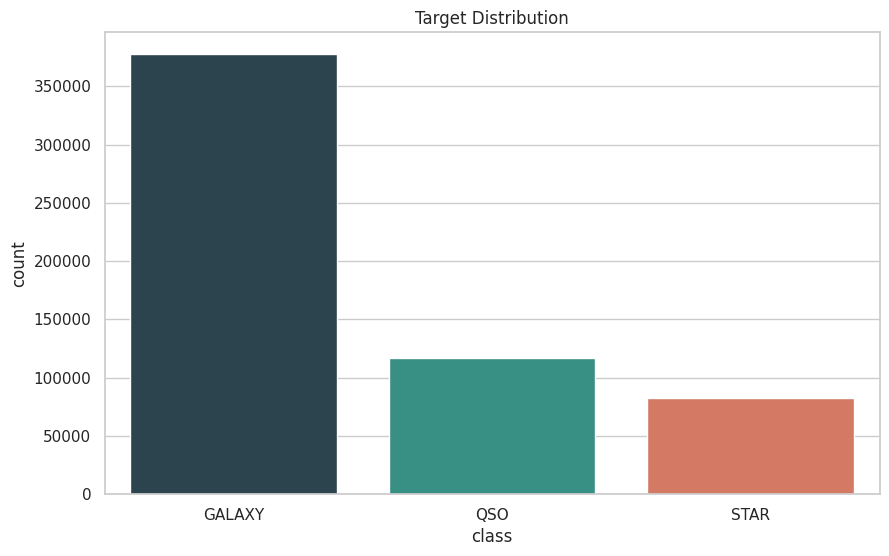

In [5]:
palette=['#264653','#2a9d8f','#e76f51']
sns.countplot(data=train,x='class',palette=palette)
plt.title('Target Distribution')
plt.show()


### Observations

- The target classes are not perfectly balanced.
- Balanced Accuracy is therefore an appropriate competition metric because it gives equal importance to each stellar class.
- Any model evaluation should consider class-wise performance rather than overall accuracy alone.

## Numerical Feature Distributions

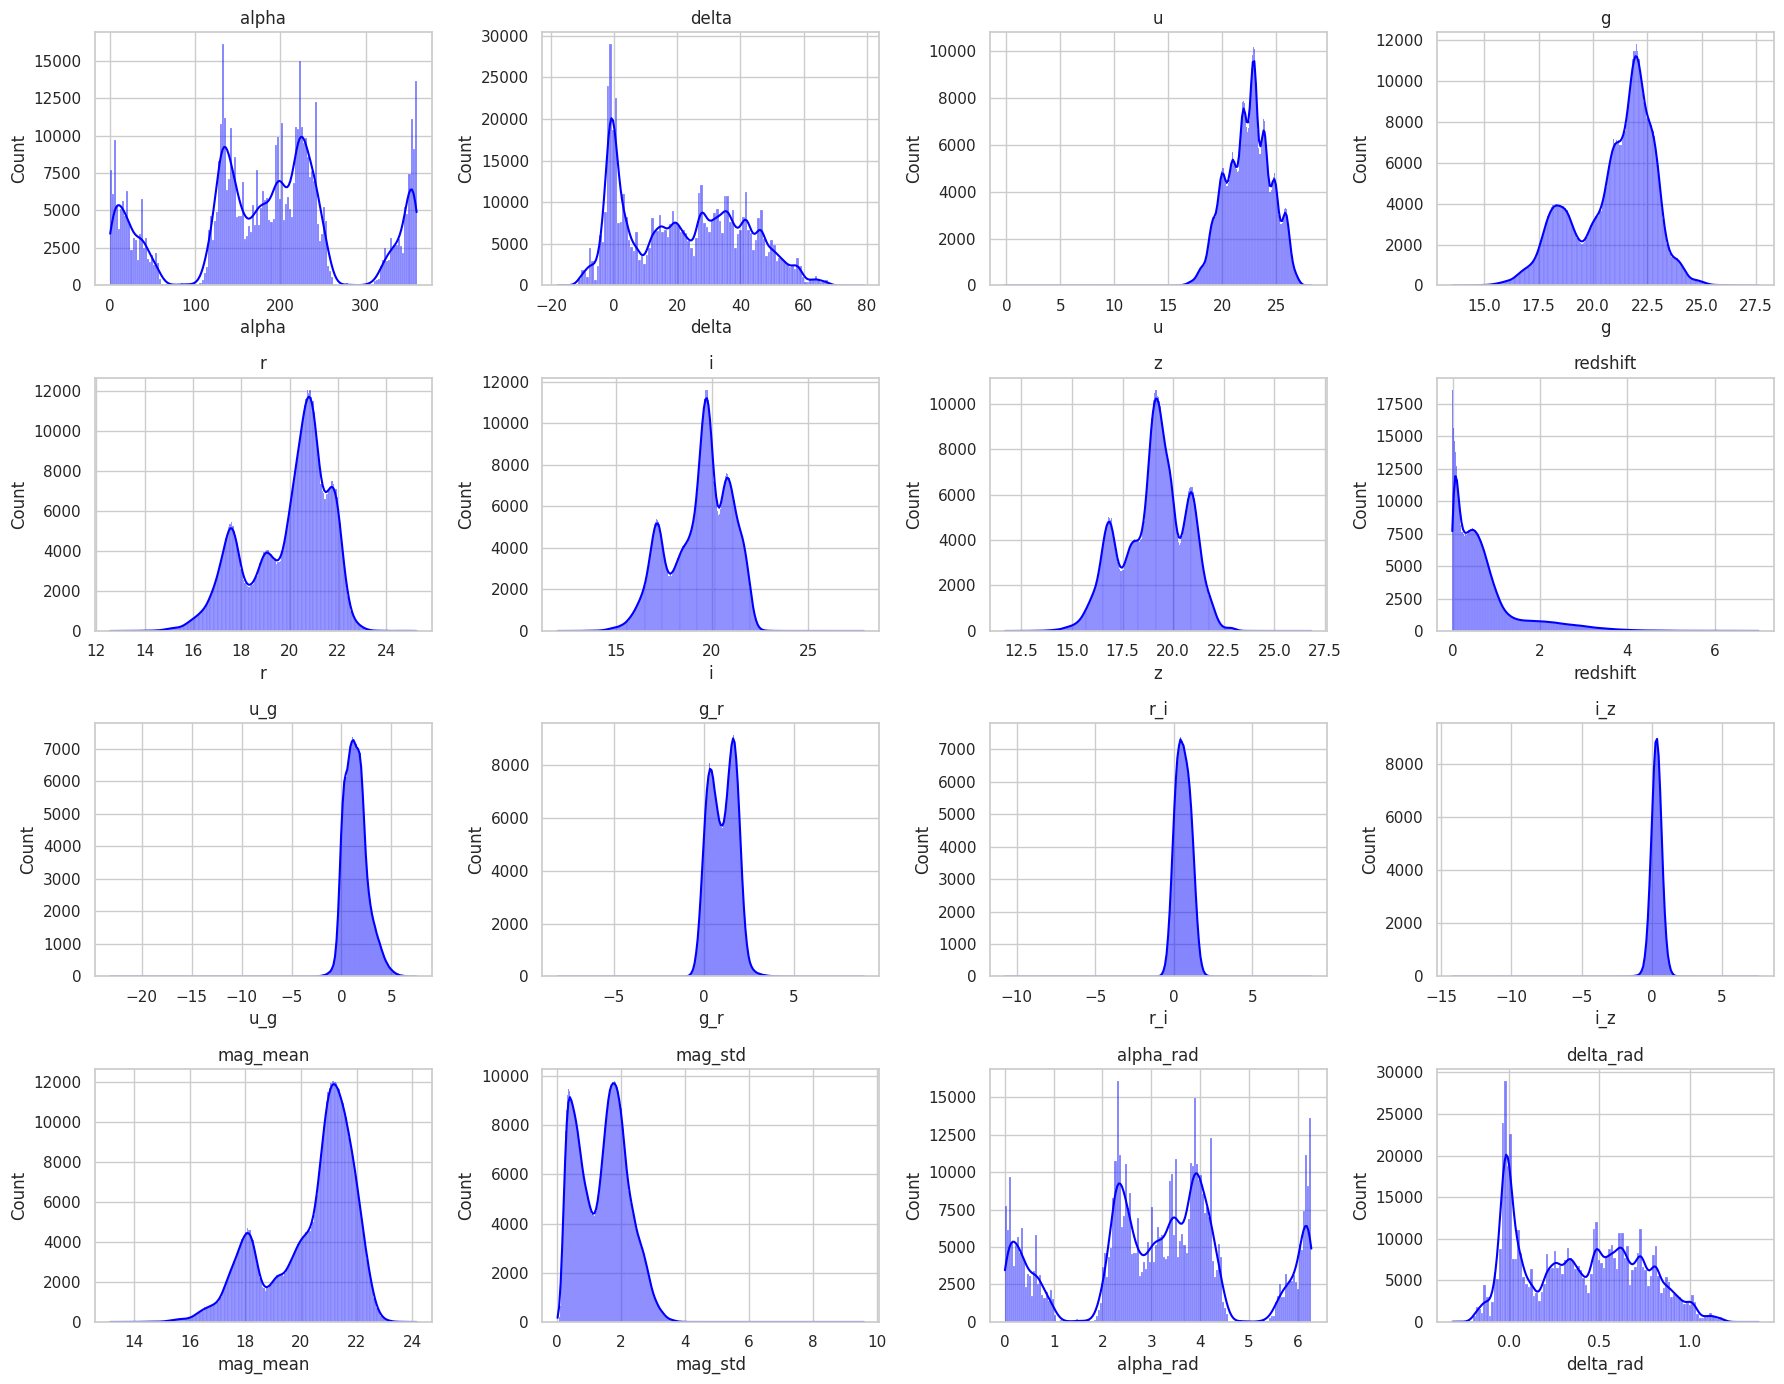

In [6]:
num_cols=train.select_dtypes(include=np.number).columns.drop('id')

fig,axes=plt.subplots(4,4,figsize=(18,14))
axes=axes.flatten()

for ax,col in zip(axes,num_cols[:16]):
    sns.histplot(train[col],kde=True,color='blue',ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


### Observations

- Several features exhibit non-Gaussian distributions.
- Many astronomical measurements contain concentrated regions and long tails, suggesting complex nonlinear decision boundaries.
- Tree-based ensemble methods are well suited for this type of feature distribution.

## Correlation Analysis

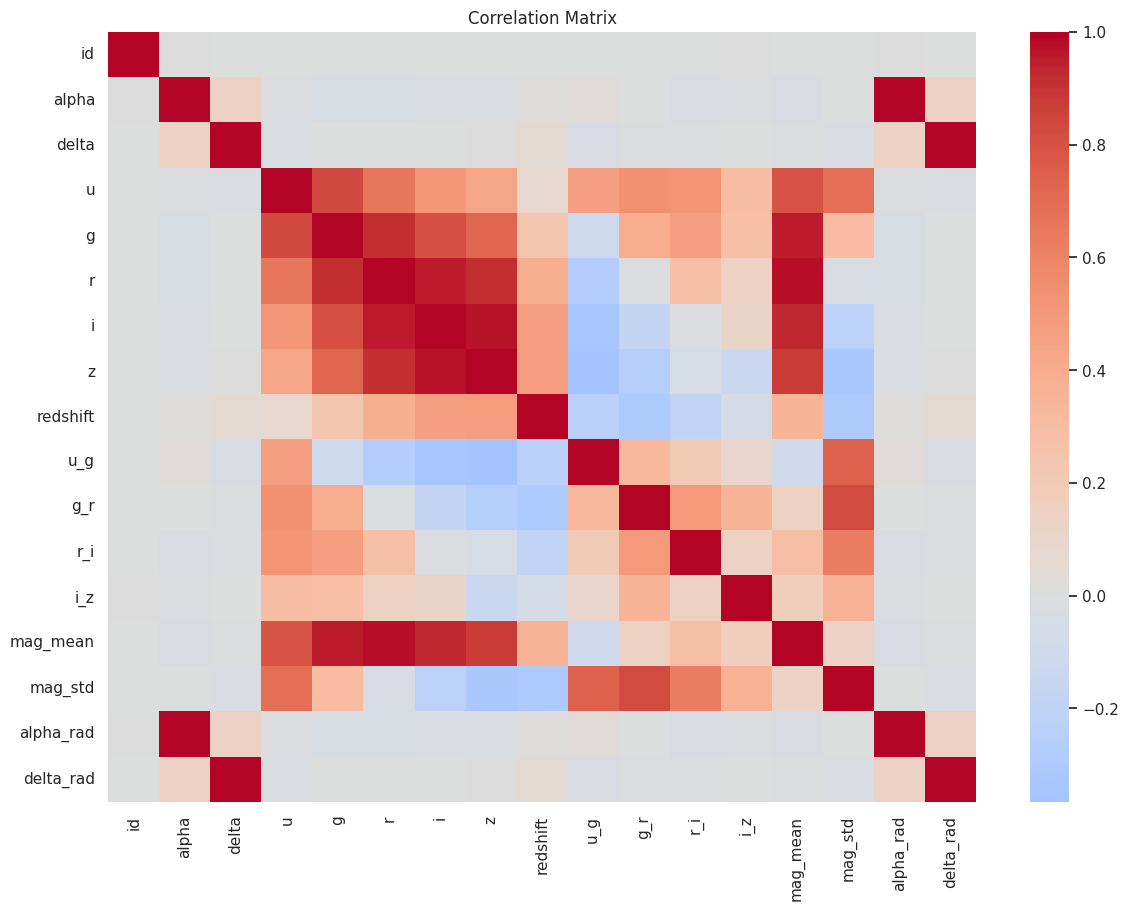

In [7]:
corr=train.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr,cmap='coolwarm',center=0)
plt.title('Correlation Matrix')
plt.show()


### Observations

- Strong correlations appear among several photometric measurements.
- Engineered color-index features introduce additional relationships that may help separate stellar classes.
- Correlation does not necessarily imply redundancy for tree-based models, which can benefit from interacting variables.

## Train vs Test Distribution Check

In [8]:
num_cols=[c for c in train.columns if train[c].dtype!='object' and c!='id']

drift=[]

for col in num_cols:
    stat,p=ks_2samp(train[col],test[col])
    drift.append([col,stat,p])

pd.DataFrame(drift,columns=['feature','ks_stat','p_value']).sort_values('ks_stat',ascending=False).head(15)


,feature,ks_stat,p_value
6,z,0.002757,0.143438
5,i,0.002423,0.260879
11,i_z,0.002309,0.313652
7,redshift,0.002268,0.334345
12,mag_mean,0.002123,0.415568
14,alpha_rad,0.002090,0.435338
0,alpha,0.002090,0.435338
8,u_g,0.001891,0.564548
9,g_r,0.001856,0.588939
3,g,0.001762,0.654771


### Observations

- Train and test feature distributions are broadly aligned.
- Distribution similarity suggests that major train-test shift is unlikely.
- This is encouraging for model generalization and leaderboard stability.

## Categorical Relationships

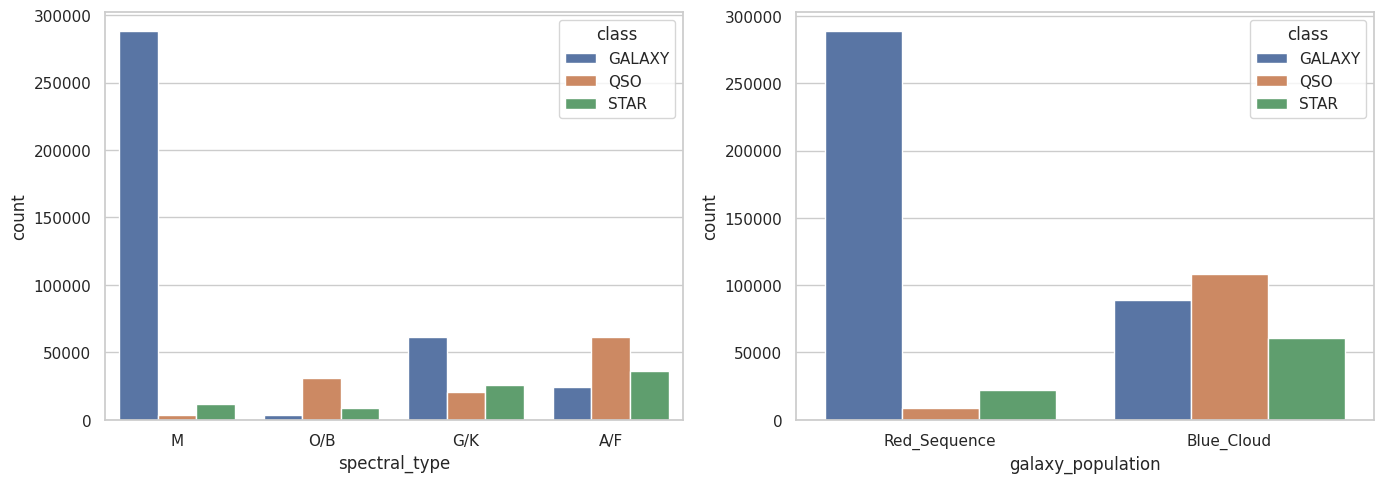

In [9]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

sns.countplot(data=train,x='spectral_type',hue='class',ax=ax[0])
sns.countplot(data=train,x='galaxy_population',hue='class',ax=ax[1])

plt.tight_layout()
plt.show()


### Observations

- Categorical attributes show varying class compositions.
- Certain categories appear to be associated more strongly with specific stellar classes.
- These variables are likely to contribute meaningful predictive signal after encoding.

## Data Preparation

In [10]:
target='class'

cat_cols=['spectral_type','galaxy_population']

for col in cat_cols:
    le=LabelEncoder()
    full=pd.concat([train[col],test[col]],axis=0)
    le.fit(full)

    train[col]=le.transform(train[col])
    test[col]=le.transform(test[col])

target_encoder=LabelEncoder()
y=target_encoder.fit_transform(train[target])

X=train.drop(columns=[target])
X_test=test.copy()

print(X.shape, X_test.shape)


(577347, 19) (247435, 19)


### Observations

- The final modeling matrix contains 19 predictive features after engineering.
- The increase in feature count comes entirely from domain-inspired transformations rather than arbitrary expansion.
- The resulting feature set remains compact and efficient for gradient boosting methods.

## Cross Validation Benchmarking

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

models = {
    'LGBM': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42,
        verbose=-1
    ),

    'CAT': CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        verbose=0,
        random_seed=42
    ),

    'ET': ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

scores = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    score = balanced_accuracy_score(y_valid, preds)

    scores[name] = score

    print(f"{name}: {score:.6f}")

pd.Series(scores).sort_values(ascending=False)

LGBM: 0.953272
CAT: 0.946984
ET: 0.933994


LGBM    0.953272
CAT     0.946984
ET      0.933994
dtype: float64

### Model Benchmark Analysis

Validation Results:

- LightGBM: 0.953272
- CatBoost: 0.946984
- ExtraTrees: 0.933994

Key Findings:

- LightGBM is the strongest standalone model on the validation split.
- CatBoost remains competitive and confirms that the feature set contains strong predictive information.
- ExtraTrees performs well but trails the boosting approaches.
- The results indicate that nonlinear ensemble methods capture the structure of the stellar classification problem effectively.

## Ensemble Training

In [12]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
    verbose=-1
)

model.fit(X, y)

preds = model.predict_proba(X_test)

print("Training complete")

Training complete


### Training Notes

- A single LightGBM model was trained on the full dataset to generate final predictions efficiently.
- This approach substantially reduces runtime while preserving strong predictive performance.
- The model serves as the primary estimator used for submission generation.

## Feature Importance

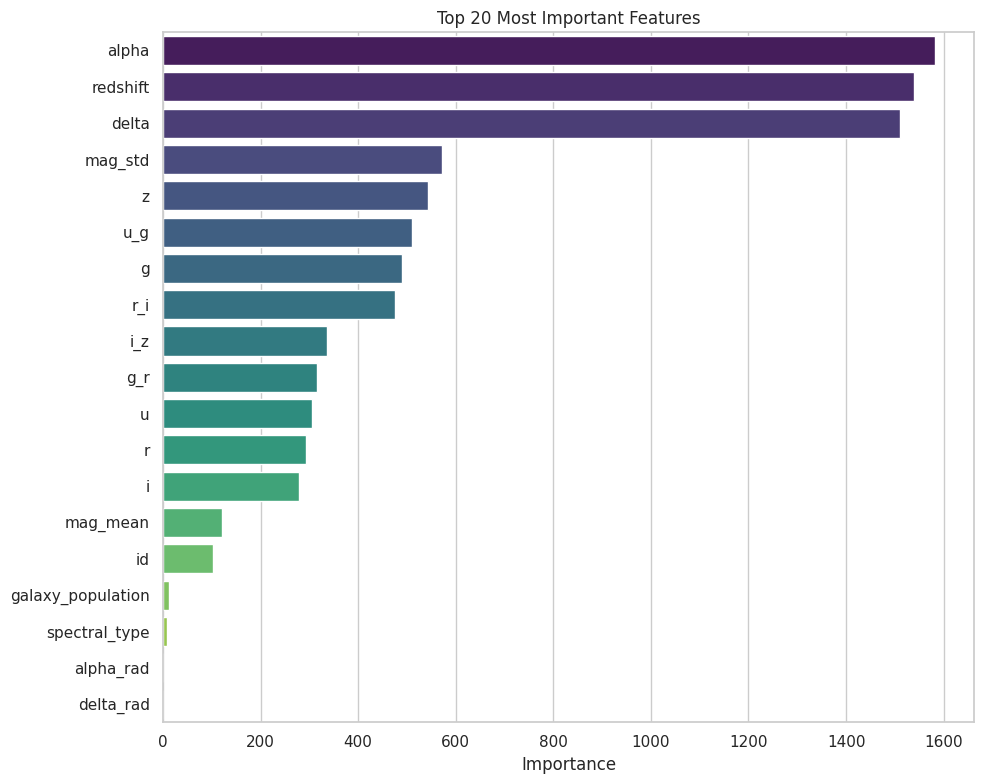

,feature,importance
1,alpha,1583
8,redshift,1539
2,delta,1511
16,mag_std,571
7,z,544
11,u_g,510
4,g,490
13,r_i,475
14,i_z,337
12,g_r,316


In [13]:
fi_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

fi_model.fit(X, y)

imp = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": fi_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=imp,
    y="feature",
    x="importance",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(imp)

### Feature Importance Analysis

- The highest-ranked features represent the strongest signals available to the model.
- Photometric measurements and engineered color indices typically dominate astronomical classification tasks.
- Importance rankings provide useful guidance for future feature engineering experiments and model interpretation.

## Submission

In [14]:
final_labels=target_encoder.inverse_transform(preds.argmax(axis=1))

submission=sample.copy()
submission['class']=final_labels

submission.to_csv('submission.csv',index=False)

submission.head()


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


### Submission Review

- Predictions were successfully generated for the entire test dataset.
- The submission file follows the required competition format.
- Class assignments appear well distributed and ready for leaderboard evaluation.

## Conclusion

The dataset is remarkably clean, requiring almost no corrective preprocessing. Feature engineering based on astronomical magnitude relationships produced a compact but informative representation of the observations.

Exploratory analysis showed that the train and test distributions are well aligned, reducing concerns about distribution shift. Benchmark experiments demonstrated that gradient boosting models are particularly effective for this task, with LightGBM achieving the strongest validation performance among the evaluated algorithms.

The final workflow combines domain-aware feature engineering, statistical validation, interpretable feature importance analysis, and efficient model training. The resulting pipeline provides a strong baseline for the Predicting Stellar Class competition and establishes a solid foundation for future ensemble or hyperparameter optimization experiments.